In [5]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv
from langchain_groq import ChatGroq
import os

In [6]:
load_dotenv()

True

In [13]:
model = ChatGroq(
    model="llama-3.1-8b-instant",   # free + fast model
    temperature=0
)

In [8]:
class Blog_state(TypedDict):
    title : str
    outline: str
    blog: str
    score: int

In [ ]:
def outline_draft(state: Blog_state) -> Blog_state:
    title = state['title']

    prompt = f"Generate an detailed outline of a blog to be created on the topic - {title}"

    response = model.invoke(prompt).content

    state['outline'] = response

    return state


def Blog_draft(state: Blog_state) -> Blog_state:
    title = state['title']
    outline = state['outline']

    prompt = f"Generate an detailed blog on the topic - {title} using following outline \n {outline}"

    response = model.invoke(prompt).content

    state['blog'] = response

    return state


def Evaluator(state: Blog_state) -> Blog_state:
    blog = state['blog']
    outline = state['outline']

    prompt = f"On rate of 1 to 10, Rate the similarity of blog- {blog} with the outline - {outline}"

    response = model.invoke(prompt).content

    state['score'] = response

    return state


In [24]:
graph = StateGraph(Blog_state)

graph.add_node('Make_outline',outline_draft)
graph.add_node('Make_Blog',Blog_draft)
graph.add_node('Blog_Evaluate',Evaluator)

graph.add_edge(START,'Make_outline')
graph.add_edge('Make_outline','Make_Blog')
graph.add_edge('Make_Blog','Blog_Evaluate')
graph.add_edge('Blog_Evaluate',END)


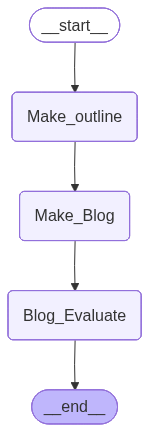

In [25]:
workflow = graph.compile()
graph.compile()

In [26]:
initial_state = {'title':'Indian Foods'}
final_state = workflow.invoke(initial_state)

print(final_state['title'])


Indian Foods


In [27]:
print(final_state['outline'])

**Title:** "Spices of India: A Journey Through the Flavors and Traditions of Indian Cuisine"

**Tagline:** "Exploring the rich culinary heritage of India, one dish at a time"

**Blog Outline:**

**I. Introduction**

* Brief overview of Indian cuisine and its significance
* Importance of food in Indian culture and traditions
* Purpose of the blog: to share knowledge, recipes, and stories about Indian food

**II. Regional Cuisine**

* **Section 1: North Indian Cuisine**
 + Overview of popular North Indian dishes (e.g. tandoori chicken, naan bread, biryani)
 + Regional specialties (e.g. Punjabi, Kashmiri, Rajasthani)
 + Recipes and cooking techniques
* **Section 2: South Indian Cuisine**
 + Overview of popular South Indian dishes (e.g. dosas, idlis, vadas)
 + Regional specialties (e.g. Tamil, Telugu, Kannada)
 + Recipes and cooking techniques
* **Section 3: East Indian Cuisine**
 + Overview of popular East Indian dishes (e.g. Bengali fish curry, jhol muri)
 + Regional specialties (e.g. Od

In [28]:
print(final_state['blog'])

**Spices of India: A Journey Through the Flavors and Traditions of Indian Cuisine**

**Tagline:** "Exploring the rich culinary heritage of India, one dish at a time"

**Introduction**

Indian cuisine is a rich and diverse tapestry of flavors, aromas, and traditions that have been woven over centuries. With its unique blend of spices, herbs, and cooking techniques, Indian food has captivated the hearts and taste buds of people around the world. In this blog, we will embark on a journey to explore the various aspects of Indian cuisine, from its regional specialties to its popular dishes, ingredients, cooking techniques, and cultural significance.

Food plays a vital role in Indian culture and traditions. Mealtimes are often seen as opportunities to bond with family and friends, share stories, and create memories. Indian cuisine is not just about sustenance; it's about love, care, and community. In this blog, we will delve into the world of Indian food, sharing recipes, cooking techniques

In [29]:
print(final_state['score'])

I would rate the similarity of the blog to the provided outline as 8 out of 10. 

The blog covers various aspects of Indian cuisine, including regional specialties, popular dishes, ingredients, cooking techniques, health and nutrition, cultural significance, and more. The outline provided is comprehensive and covers all these aspects, making it a good match for the blog.

However, there are a few areas where the blog and the outline differ:

1. The blog has a more detailed and in-depth discussion of each topic, while the outline provides a general overview.
2. The blog includes more recipes and cooking techniques, while the outline only provides a brief overview of each section.
3. The blog has a more conversational tone, while the outline is more formal and structured.

Overall, the blog and the outline share a similar structure and content, but the blog provides more detail and depth in each section.
